#Rumour simulation
In this simulation, the spreading of a rumour is simulated via agents moving around a network

In [1]:
"""
Rumour Spread Simulation — Data Generation
Rebuilding our Village model to produce a rich dataset for statistical analysis.
"""

import mesa
import networkx as nx
import numpy as np
import pandas as pd
import random
from collections import Counter
import matplotlib.pyplot as plt
from scipy import stats



random.seed(42)
np.random.seed(42)

# ── World ──────────────────────────────────────────────────────────────────
NUM_ROOMS = 60
NUM_AGENTS = 60
NUM_STEPS = 40
NUM_RUNS = 50

world = nx.watts_strogatz_graph(n=NUM_ROOMS, k=4, p=0.15, seed=42)

In [2]:
class Villager(mesa.Agent):
    def __init__(self, model, sociability, scepticism):
        super().__init__(model)
        self.sociability = sociability
        self.scepticism = scepticism
        self.knows_rumour = False
        self.room = None
        self.spread_count = 0
        self.heard_at_step = None

    def step(self):
        # Move to a random neighbouring room
        neighbours = list(world.neighbors(self.room))
        if neighbours:
            self.room = random.choice(neighbours)

        # Try to spread rumour to agents in the same room
        if self.knows_rumour:
            for other in self.model.agents:
                if other is not self and other.room == self.room:
                    if not other.knows_rumour:
                        # Spread probability: sociability vs scepticism
                        p = max(0.0, self.sociability - other.scepticism * 0.5)
                        if random.random() < p:
                            other.knows_rumour = True
                            other.heard_at_step = self.model.current_step
                            self.spread_count += 1
                            self.model.spread_log[self.room] += 1




In [3]:
class VillageModel(mesa.Model):
    def __init__(self):
        super().__init__()
        self.current_step = 0
        self.spread_log = Counter()

        for _ in range(NUM_AGENTS):
            soc = random.uniform(0.3, 1.0)
            skep = random.uniform(0.0, 0.7)
            agent = Villager(self, sociability=soc, scepticism=skep)
            agent.room = random.randint(0, NUM_ROOMS - 1)
            self.agents.add(agent)

    def step(self):
        self.current_step += 1
        self.agents.shuffle_do("step")



In [4]:
degree = dict(world.degree())
records = []
all_spread_counts = Counter()

In [5]:
for run in range(NUM_RUNS):
    model = VillageModel()

    # Patient zero
    patient_zero = random.choice(list(model.agents))
    patient_zero.knows_rumour = True
    patient_zero.heard_at_step = 0

    for _ in range(NUM_STEPS):
        model.step()

    all_spread_counts.update(model.spread_log)

    for agent in model.agents:
        records.append({
            "run": run,
            "agent_id": agent.unique_id,
            "sociability": round(agent.sociability, 4),
            "scepticism": round(agent.scepticism, 4),
            "spread_count": agent.spread_count,
            "knows_rumour": agent.knows_rumour,
            "heard_at_step": agent.heard_at_step,
            "final_room": agent.room,
        })

# Build agent-level DataFrame
df = pd.DataFrame(records)

# Add room degree for the agent's final room
df['room_degree'] = df['final_room'].map(degree)

# Create categorical bins for analysis
df['soc_group'] = pd.cut(df['sociability'], bins=3, labels=['Low', 'Medium', 'High'])
df['skep_group'] = pd.cut(df['scepticism'], bins=3, labels=['Low', 'Medium', 'High'])

# Build room-level DataFrame
room_df = pd.DataFrame({
    "room": list(degree.keys()),
    "degree": list(degree.values()),
    "total_spreads": [all_spread_counts.get(room, 0) for room in degree.keys()]
})

# ── Quick summary ──────────────────────────────────────────────────────────
print(f"Agent DataFrame: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Room DataFrame: {room_df.shape[0]} rows × {room_df.shape[1]} columns")
print()
print("=== Agent data columns ===")
print(df.dtypes)
print()
print("=== Sample rows ===")
print(df.head(10).to_string())
print()
print(f"Agents who heard the rumour: {df['knows_rumour'].sum()} / {len(df)} ({df['knows_rumour'].mean():.1%})")
print(f"Mean heard_at_step (for those who heard): {df['heard_at_step'].dropna().mean():.1f}")
print(f"Mean spread_count: {df['spread_count'].mean():.2f}")


Agent DataFrame: 3000 rows × 11 columns
Room DataFrame: 60 rows × 3 columns

=== Agent data columns ===
run                 int64
agent_id            int64
sociability       float64
scepticism        float64
spread_count        int64
knows_rumour         bool
heard_at_step     float64
final_room          int64
room_degree         int64
soc_group        category
skep_group       category
dtype: object

=== Sample rows ===
   run  agent_id  sociability  scepticism  spread_count  knows_rumour  heard_at_step  final_room  room_degree soc_group skep_group
0    0         1       0.7476      0.0175             3          True           17.0          32            4    Medium        Low
1    0         2       0.4714      0.0977             0          True           19.0          54            4       Low        Low
2    0         3       0.7737      0.6245             0          True           22.0          59            4      High       High
3    0         4       0.7133      0.0222          

In [6]:
df.head(10)

,run,agent_id,sociability,scepticism,spread_count,knows_rumour,heard_at_step,final_room,room_degree,soc_group,skep_group
0,0,1,0.7476,0.0175,3,True,17.0,32,4,Medium,Low
1,0,2,0.4714,0.0977,0,True,19.0,54,4,Low,Low
2,0,3,0.7737,0.6245,0,True,22.0,59,4,High,High
3,0,4,0.7133,0.0222,1,True,15.0,16,4,Medium,Low
4,0,5,0.4530,0.3537,0,True,17.0,2,3,Low,Medium
5,0,6,0.6929,0.5012,5,True,4.0,6,6,Medium,High
6,0,7,0.6815,0.1543,1,True,18.0,44,4,Medium,Low
7,0,8,0.4947,0.6085,0,True,22.0,55,4,Low,High
8,0,9,0.8641,0.4887,2,True,20.0,47,4,High,High
9,0,10,0.4945,0.1507,0,True,19.0,39,4,Low,Low


In [7]:
df.dtypes

run                 int64
agent_id            int64
sociability       float64
scepticism        float64
spread_count        int64
knows_rumour         bool
heard_at_step     float64
final_room          int64
room_degree         int64
soc_group        category
skep_group       category
dtype: object

In [8]:
df['spread_count'].describe()

count    3000.000000
mean        0.970000
std         1.468271
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        11.000000
Name: spread_count, dtype: float64

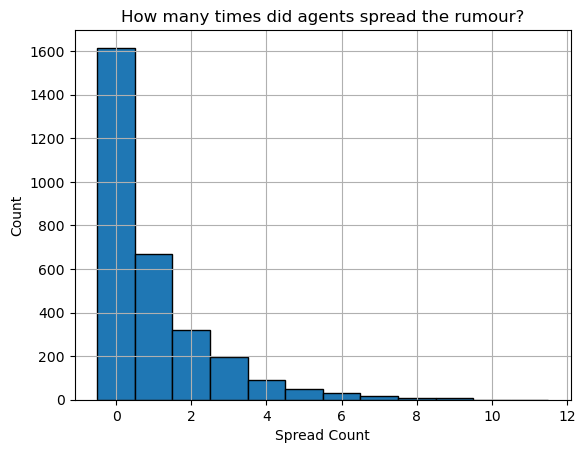

In [9]:
df['spread_count'].hist(bins=range(0, df['spread_count'].max() + 2), 
                         edgecolor='black', align='left')
plt.xlabel('Spread Count')
plt.ylabel('Count')
plt.title('How many times did agents spread the rumour?')
plt.show()

In [10]:
df['spread_count'].skew()

np.float64(2.144731746523417)

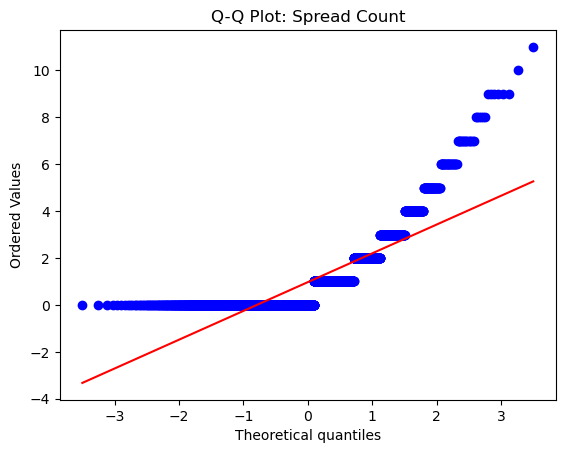

In [11]:
stats.probplot(df['spread_count'], plot=plt)
plt.title('Q-Q Plot: Spread Count')
plt.show()

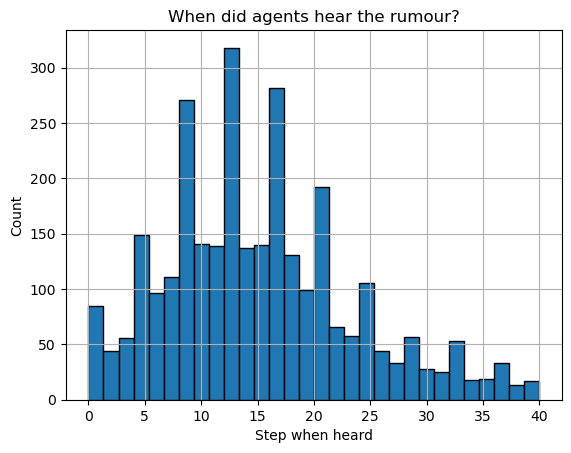

In [12]:
df['heard_at_step'].hist(bins=30, edgecolor='black')
plt.xlabel('Step when heard')
plt.ylabel('Count')
plt.title('When did agents hear the rumour?')
plt.show()

In [13]:
df['heard_at_step'].skew()

np.float64(0.6269778474501823)

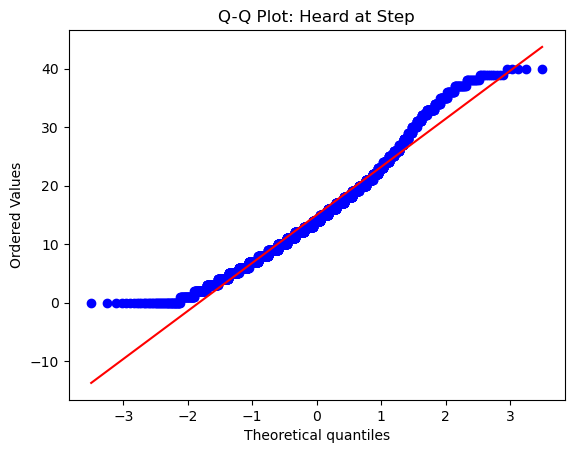

In [14]:
stats.probplot(df['heard_at_step'].dropna(), plot=plt)
plt.title('Q-Q Plot: Heard at Step')
plt.show()

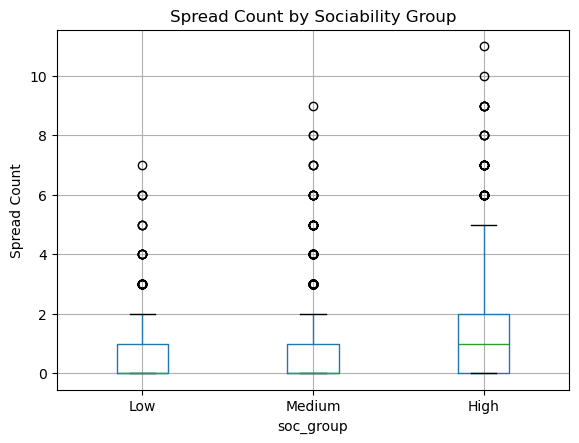

In [15]:
df.boxplot(column='spread_count', by='soc_group')
plt.title('Spread Count by Sociability Group')
plt.suptitle('')
plt.ylabel('Spread Count')
plt.show()

In [16]:
from scipy import stats

low = df[df['soc_group'] == 'Low']['spread_count']
med = df[df['soc_group'] == 'Medium']['spread_count']
high = df[df['soc_group'] == 'High']['spread_count']

stat, p = stats.kruskal(low, med, high)
print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.6f}")

Kruskal-Wallis H = 153.045, p = 0.000000


In [17]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(df, val_col='spread_count', group_col='soc_group', p_adjust='bonferroni')
print(dunn)

                 Low        Medium          High
Low     1.000000e+00  1.383900e-11  1.618637e-34
Medium  1.383900e-11  1.000000e+00  1.047100e-07
High    1.618637e-34  1.047100e-07  1.000000e+00


In [18]:
df.groupby('soc_group')['spread_count'].mean()

/var/folders/wj/xzbvl19s7qdg2sxs_dz30hb80000gn/T/ipykernel_75452/1474083499.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('soc_group')['spread_count'].mean()


soc_group
Low       0.528056
Medium    0.956820
High      1.432350
Name: spread_count, dtype: float64

In [19]:
n = len(df)
epsilon_sq = stat / ((n**2 - 1) / (n + 1))
print(f"ε² = {epsilon_sq:.4f}")

ε² = 0.0510


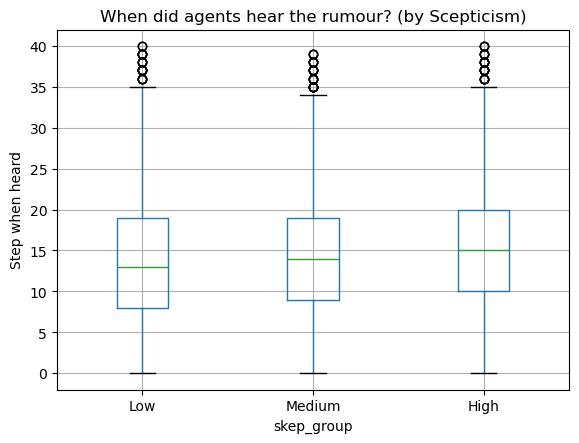

In [20]:
df.boxplot(column='heard_at_step', by='skep_group')
plt.title('When did agents hear the rumour? (by Scepticism)')
plt.suptitle('')
plt.ylabel('Step when heard')
plt.show()

In [21]:
low_s = df[df['skep_group'] == 'Low']['heard_at_step'].dropna()
med_s = df[df['skep_group'] == 'Medium']['heard_at_step'].dropna()
high_s = df[df['skep_group'] == 'High']['heard_at_step'].dropna()

stat, p = stats.f_oneway(low_s, med_s, high_s)
print(f"F = {stat:.3f}, p = {p:.6f}")

F = 6.325, p = 0.001815


In [22]:
# We need the sum of squares — let's use statsmodels for this
from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols('heard_at_step ~ C(skep_group)', data=df.dropna(subset=['heard_at_step'])).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                      sum_sq      df         F    PR(>F)
C(skep_group)     875.599153     2.0  6.325416  0.001815
Residual       204662.172468  2957.0       NaN       NaN


In [23]:
eta_sq = 875.60 / (875.60 + 204662.17)
print(f"η² = {eta_sq:.4f}")

η² = 0.0043


In [24]:
spreaders = df[df['spread_count'] > 0]['sociability']
non_spreaders = df[df['spread_count'] == 0]['sociability']

print(f"Spreaders: n={len(spreaders)}, mean={spreaders.mean():.3f}")
print(f"Non-spreaders: n={len(non_spreaders)}, mean={non_spreaders.mean():.3f}")

Spreaders: n=1384, mean=0.692
Non-spreaders: n=1616, mean=0.610


In [25]:
stat, p = stats.ttest_ind(spreaders, non_spreaders, equal_var=False)
print(f"Welch's t-test: t = {stat:.3f}, p = {p:.6f}")

Welch's t-test: t = 11.297, p = 0.000000


In [26]:
stat, p = stats.mannwhitneyu(spreaders, non_spreaders, alternative='two-sided')
print(f"Mann-Whitney U = {stat:.1f}, p = {p:.6f}")

Mann-Whitney U = 1379579.5, p = 0.000000


In [27]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(spreaders, non_spreaders)
print(f"Cohen's d = {d:.3f}")

Cohen's d = 0.413


In [28]:
r, p = stats.pearsonr(df['sociability'], df['spread_count'])
print(f"Pearson r = {r:.3f}, p = {p:.6f}")

Pearson r = 0.274, p = 0.000000


In [29]:
rho, p = stats.spearmanr(df['sociability'], df['spread_count'])
print(f"Spearman ρ = {rho:.3f}, p = {p:.6f}")

Spearman ρ = 0.252, p = 0.000000


In [30]:
r, p = stats.pearsonr(df['scepticism'], df['spread_count'])
print(f"Scepticism vs spread_count: Pearson r = {r:.3f}, p = {p:.6f}")

Scepticism vs spread_count: Pearson r = -0.090, p = 0.000001


In [31]:
cols = ['sociability', 'scepticism', 'spread_count', 'heard_at_step', 'room_degree']
print(df[cols].corr().round(3))

               sociability  scepticism  spread_count  heard_at_step  \
sociability          1.000       0.010         0.274          0.004   
scepticism           0.010       1.000        -0.090          0.072   
spread_count         0.274      -0.090         1.000         -0.374   
heard_at_step        0.004       0.072        -0.374          1.000   
room_degree          0.006      -0.019        -0.015         -0.001   

               room_degree  
sociability          0.006  
scepticism          -0.019  
spread_count        -0.015  
heard_at_step       -0.001  
room_degree          1.000  


In [32]:
from statsmodels.formula.api import ols

model = ols('spread_count ~ sociability', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           spread_count   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     243.9
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           6.43e-53
Time:                        00:34:57   Log-Likelihood:                -5291.3
No. Observations:                3000   AIC:                         1.059e+04
Df Residuals:                    2998   BIC:                         1.060e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.3284      0.087     -3.773      

In [33]:
model2 = ols('spread_count ~ sociability + scepticism', data=df).fit()
print(f"R² with just sociability: 0.075")
print(f"R² with both: {model2.rsquared:.3f}")
print()
print(model2.params)


R² with just sociability: 0.075
R² with both: 0.084

Intercept     -0.097178
sociability    2.010898
scepticism    -0.672771
dtype: float64


In [34]:
from statsmodels.formula.api import glm
import statsmodels.api as sm

poisson_model = glm('spread_count ~ sociability + scepticism', data=df,
                     family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           spread_count   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2997
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4307.1
Date:                Tue, 10 Mar 2026   Deviance:                       5164.4
Time:                        00:36:40   Pearson chi2:                 5.71e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1720
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.2739      0.079    -16.127      

In [35]:
print(f"Deviance: {poisson_model.deviance:.1f}")
print(f"df: {poisson_model.df_resid}")
print(f"Ratio: {poisson_model.deviance / poisson_model.df_resid:.2f}")

Deviance: 5164.4
df: 2997
Ratio: 1.72


In [36]:
df['is_spreader'] = (df['spread_count'] > 0).astype(int)
print(df['is_spreader'].value_counts())

is_spreader
0    1616
1    1384
Name: count, dtype: int64


In [37]:
from statsmodels.formula.api import logit

log_model = logit('is_spreader ~ sociability + scepticism', data=df).fit()
print(log_model.summary())

Optimization terminated successfully.
         Current function value: 0.665693
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            is_spreader   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2997
Method:                           MLE   Df Model:                            2
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                 0.03544
Time:                        00:38:39   Log-Likelihood:                -1997.1
converged:                       True   LL-Null:                       -2070.5
Covariance Type:            nonrobust   LLR p-value:                 1.348e-32
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.2025      0.143     -8.426      0.000      -1.482      -0.923
sociability     2.0900    

In [38]:
print("Odds ratios:")
print(np.exp(log_model.params))

Odds ratios:
Intercept      0.300431
sociability    8.084700
scepticism     0.407640
dtype: float64


In [39]:
from sklearn.preprocessing import StandardScaler

features = df[['sociability', 'scepticism', 'spread_count']].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Shape: {features_scaled.shape}")
print(f"Mean of each column (should be ~0): {features_scaled.mean(axis=0).round(3)}")
print(f"Std of each column (should be ~1):  {features_scaled.std(axis=0).round(3)}")

Shape: (3000, 3)
Mean of each column (should be ~0): [ 0. -0.  0.]
Std of each column (should be ~1):  [1. 1. 1.]


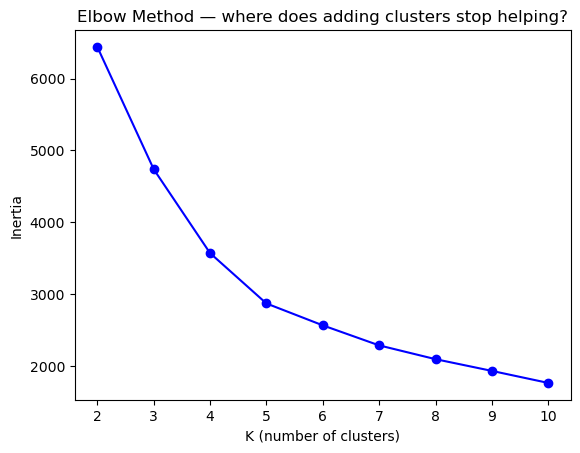

In [40]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method — where does adding clusters stop helping?')
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    s = silhouette_score(features_scaled, labels)
    print(f"K={k}: silhouette = {s:.3f}")

K=2: silhouette = 0.285
K=3: silhouette = 0.306
K=4: silhouette = 0.319
K=5: silhouette = 0.316
K=6: silhouette = 0.316
K=7: silhouette = 0.320


In [42]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(features_scaled)

df.groupby('cluster')[['sociability', 'scepticism', 'spread_count']].mean().round(3)

,sociability,scepticism,spread_count
cluster,,,
0,0.503,0.535,0.412
1,0.849,0.375,0.621
2,0.514,0.158,0.570
3,0.801,0.315,4.176


In [43]:
df['cluster'].value_counts().sort_index()

cluster
0    848
1    920
2    875
3    357
Name: count, dtype: int64

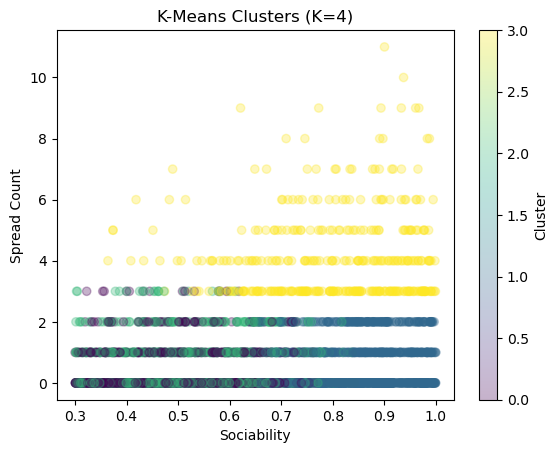

In [44]:
plt.scatter(df['sociability'], df['spread_count'], c=df['cluster'], 
            cmap='viridis', alpha=0.3)
plt.xlabel('Sociability')
plt.ylabel('Spread Count')
plt.title('K-Means Clusters (K=4)')
plt.colorbar(label='Cluster')
plt.show()

In [45]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(features_scaled)

n_clusters = len(set(db_labels) - {-1})
n_noise = (db_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

Clusters found: 11
Noise points: 54


In [46]:
for e in [0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=e, min_samples=5)
    labels = db.fit_predict(features_scaled)
    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    print(f"eps={e}: {n_clusters} clusters, {n_noise} noise points")

eps=0.5: 11 clusters, 54 noise points
eps=0.7: 1 clusters, 22 noise points
eps=1.0: 1 clusters, 4 noise points
eps=1.5: 1 clusters, 1 noise points


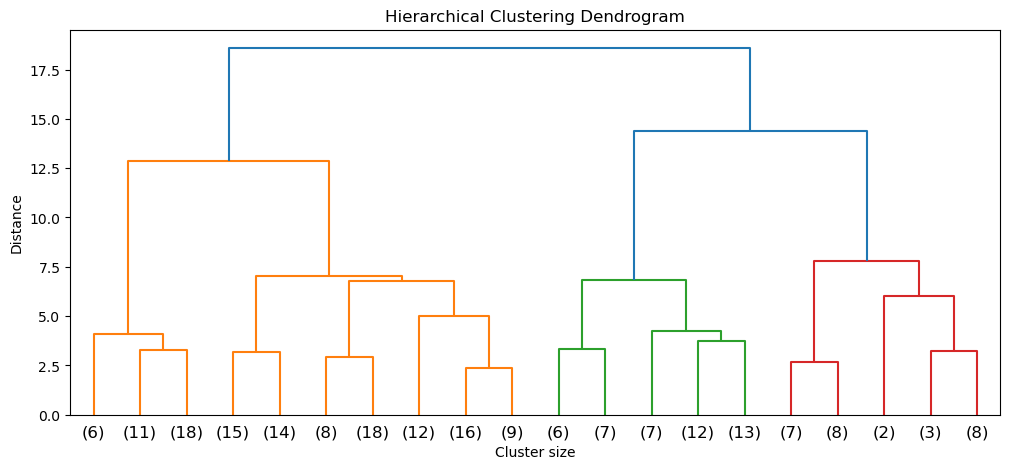

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a random sample — dendrograms get messy with 3000 points
sample_idx = df.sample(200, random_state=42).index
sample_scaled = features_scaled[sample_idx]

Z = linkage(sample_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()